# Architecture 3 v4 - Prompt Profiling Pipeline

v4 keeps the v3 two-stage architecture and adds:

- expanded/audited v4 dataset
- rubric-aligned D3/D5 feature naming
- targeted features for Output Formality and Context Requirement
- cost-sensitive T3 weighting
- boundary-aware final tier policy
- v4 model artifact names

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report, accuracy_score
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)

print("All imports successful.")

All imports successful.


---
## Helper Functions

In [2]:
# -- Score <-> class mappings -------------------------------------------------
SCORE_TO_CLASS = {0.0: 0, 0.25: 1, 0.50: 2, 0.75: 3, 1.0: 4}
CLASS_TO_SCORE = {0: 0.0, 1: 0.25, 2: 0.50, 3: 0.75, 4: 1.0}
TIER_TO_INT = {'T1': 0, 'T2': 1, 'T3': 2}
INT_TO_TIER = {0: 'T1', 1: 'T2', 2: 'T3'}

DIMENSION_LABELS = {
    'D1': 'Semantic Complexity',
    'D2': 'Domain Specificity',
    'D3': 'Output Formality',
    'D4': 'Research Dependency',
    'D5': 'Context Requirement',
}

BOUNDARY_WINDOWS = ((0.35, 0.45), (0.65, 0.75))


def complexity_score(d1, d2, d3, d4, d5):
    """Compute weighted complexity score from the source rubric."""
    return (d1 * 0.35) + (d2 * 0.20) + (d3 * 0.20) + (d4 * 0.15) + (d5 * 0.10)


def get_tier(score):
    """Map complexity score to tier."""
    if score < 0.40:
        return 'T1'
    if score < 0.70:
        return 'T2'
    return 'T3'


def is_boundary_score(score):
    """Return True when a score is close to a tier boundary."""
    return any(lo <= score < hi for lo, hi in BOUNDARY_WINDOWS)


def choose_final_tier(stage1_int, derived_int, derived_score):
    """Boundary-aware tier policy.

    Rules:
      1. If both models agree, keep that tier.
      2. Protect likely T3 prompts from under-routing.
      3. Near tier boundaries, trust the direct tier classifier.
      4. Away from boundaries, trust the dimension-derived score.
    """
    if stage1_int == derived_int:
        return stage1_int

    t3 = TIER_TO_INT['T3']
    if stage1_int == t3 and derived_score >= 0.65:
        return stage1_int
    if derived_int == t3 and derived_score >= 0.70:
        return derived_int

    if is_boundary_score(derived_score):
        return stage1_int

    return derived_int


# Sanity checks
assert get_tier(0.10) == 'T1'
assert get_tier(0.55) == 'T2'
assert get_tier(0.85) == 'T3'
assert choose_final_tier(TIER_TO_INT['T2'], TIER_TO_INT['T3'], 0.71) == TIER_TO_INT['T3']
print("Helper functions verified.")

Helper functions verified.


In [3]:
def extract_handcrafted_features(prompt, phrasing_style=None):
    """Extract rubric-aligned structural features.

    D3 is Output Formality.
    D5 is Context Requirement.
    D4 is Research Dependency.
    """
    text = str(prompt).lower()
    words = text.split()
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]

    attachment_terms = [
        'attached', 'uploaded', 'pasted', 'screenshot', 'file attached',
        'the attached', 'i have uploaded', "i've uploaded", 'uploaded corpus',
        'context bundle', 'full archive', 'evidence folder'
    ]
    formal_outputs = [
        'requirements document', 'technical specification', 'specification',
        'executive summary', 'roadmap', 'framework', 'architecture',
        'policy', 'checklist', 'runbook', 'report', 'proposal', 'strategy',
        'matrix', 'blueprint', 'playbook', 'operating model'
    ]
    package_outputs = [
        'package', 'appendix', 'annex', 'toc', 'table of contents',
        'evidence mapping', 'risk register', 'cost model', 'governance controls'
    ]

    features = {
        # Text statistics
        'word_count': len(words),
        'char_count': len(text),
        'sentence_count': max(len(sentences), 1),
        'avg_word_length': np.mean([len(w) for w in words]) if words else 0,
        'question_marks': text.count('?'),
        'comma_count': text.count(','),

        # D5: Context requirement
        'has_attachment': int(any(kw in text for kw in attachment_terms)),
        'provided_artifact_count': sum(1 for kw in [
            'diagram', 'log', 'export', 'contract', 'catalog', 'policy',
            'evidence', 'inventory', 'ticket', 'postmortem', 'dashboard',
            'configuration', 'archive', 'corpus'
        ] if kw in text),
        'large_context_signal': int(any(kw in text for kw in [
            'full uploaded', 'complete uploaded', 'full archive', 'complete corpus',
            'three years', 'two years', '18 months', 'multi-document',
            'all documents', 'extended conversation', 'context bundle'
        ])),
        'multi_document_signal': int(any(kw in text for kw in [
            'and', 'multiple', 'across', 'bundle', 'corpus', 'archive'
        ]) and any(kw in text for kw in attachment_terms)),

        # D3: Output formality
        'has_formal_deliverable': int(any(kw in text for kw in formal_outputs)),
        'has_report_package': int(any(kw in text for kw in package_outputs)),
        'has_long_output_signal': int(any(kw in text for kw in [
            'comprehensive', 'enterprise-grade', 'formal', 'detailed',
            'full', 'complete', 'end-to-end', 'appendix-level'
        ])),
        'structured_section_count': sum(1 for kw in [
            'executive summary', 'gap analysis', 'roadmap', 'risk register',
            'implementation plan', 'success metrics', 'dependencies',
            'recommendations', 'findings', 'appendix'
        ] if kw in text),

        # D1: Semantic complexity
        'has_scope_words': int(any(kw in text for kw in [
            'multi-stage', 'cross-domain', 'strategic', 'synthesize',
            'root causes', 'prioritized', 'tradeoffs', 'decision',
            'governance', 'operating model'
        ])),
        'action_verb_count': sum(1 for kw in [
            'build', 'design', 'evaluate', 'draft', 'develop', 'create',
            'produce', 'generate', 'implement', 'establish', 'restructure',
            'migrate', 'optimize', 'analyze', 'recommend'
        ] if kw in text),
        'multi_stage_signal': int(any(kw in text for kw in [
            'phase', 'phased', 'step-by-step', 'roadmap', 'workflow',
            'implementation', 'migration', 'operating model'
        ])),

        # D2: Domain specificity
        'has_compliance': int(any(kw in text for kw in [
            'nist', 'hipaa', 'gdpr', 'soc 2', 'soc2', 'iso 27001',
            'pci dss', 'eu ai act', 'ccpa', 'cpra', 'fcra', 'eeoc',
            'regulatory', 'control library'
        ])),
        'cloud_providers_mentioned': sum(1 for kw in ['aws', 'azure', 'gcp', 'google cloud'] if kw in text),
        'systems_mentioned': sum(1 for kw in [
            'salesforce', 'sap', 'workday', 'hubspot', 'jira', 'servicenow',
            'okta', 'terraform', 'kubernetes', 'kafka', 'snowflake',
            'databricks', 'mulesoft', 'boomi', 'bigquery', 'bedrock',
            'vertex ai', 'openai'
        ] if kw in text),
        'domain_framework_count': sum(1 for kw in [
            'finops', 'ai governance', 'purdue model', 'zero trust',
            'data mesh', 'devsecops', 'itil', 'nist ai rmf'
        ] if kw in text),

        # D4: Research dependency
        'external_data_score': min(1.0, sum(1 for kw in [
            'market research', 'competitive analysis', 'analyst report',
            'industry trends', 'industry benchmark', 'latest pricing',
            'current pricing', 'current market', 'vendor pricing',
            'vendor comparison', 'compare vendors', 'real-time pricing',
            'pricing models', 'pricing tiers', 'competitor', 'survey data',
            'gartner', 'forrester', 'benchmark data', 'market rates',
            'regulatory updates', 'latest vendor documentation'
        ] if kw in text) / 3.0),
        'has_time_reference': int(any(kw in text for kw in [
            'this quarter', 'this month', 'last quarter', 'last month',
            'next quarter', 'this year', 'current', 'latest', 'recent',
            'real-time', 'today'
        ])),
        'vendor_tool_count': sum(1 for kw in [
            'openai', 'anthropic', 'cohere', 'google', 'microsoft',
            'stripe', 'twilio', 'segment', 'tealium', 'mparticle',
            'sailpoint', 'saviynt', 'cyberark', 'sift', 'forter',
            'mulesoft', 'boomi', 'splunk', 'datadog', 'pagerduty'
        ] if kw in text),
        'has_market_terms': int(any(kw in text for kw in [
            'market', 'pricing', 'vendor', 'competitor', 'benchmark',
            'industry', 'gartner', 'cost of', 'salary survey'
        ])),
        'has_cost_comparison': int(any(kw in text for kw in [
            'cost comparison', 'price comparison', 'total cost of ownership',
            'tco', 'roi projection', 'cost-benefit', 'cost benefit',
            'cost savings', 'pay bands', 'compensation benchmark'
        ])),

        # Boundary / production risk signals
        'has_comparison': int(any(kw in text for kw in [
            ' vs ', 'versus', 'compare', 'comparison', 'difference between',
            'differ', 'comparing'
        ])),
        'stakeholder_mentions': sum(1 for kw in [
            'ceo', 'cto', 'cfo', 'ciso', 'cmo', 'board', 'executive',
            'leadership', 'director', 'vp of', 'vice president'
        ] if kw in text),
        'risk_language': int(any(kw in text for kw in [
            'liability', 'exposure', 'penalty', 'breach', 'violation',
            'lawsuit', 'audit', 'compliance gap', 'risk assessment',
            'risk posture', 'remediation'
        ])),

        # Phrasing style
        'phrasing_explicit': 0,
        'phrasing_implicit': 0,
        'phrasing_vague': 0,
    }

    if phrasing_style:
        style = str(phrasing_style).lower().strip()
        if style == 'explicit':
            features['phrasing_explicit'] = 1
        elif style == 'implicit':
            features['phrasing_implicit'] = 1
        elif style == 'vague':
            features['phrasing_vague'] = 1

    return features


test_feats = extract_handcrafted_features(
    "Using the complete uploaded corpus, research latest AWS and Azure pricing and produce an executive summary, risk register, roadmap, and appendix-level evidence mapping",
    phrasing_style="explicit"
)
print(f"Feature count: {len(test_feats)}")
print(f"D3/D5 features: formal={test_feats['has_formal_deliverable']}, "
      f"large_context={test_feats['large_context_signal']}, artifacts={test_feats['provided_artifact_count']}")
print(f"D4 features: external={test_feats['external_data_score']:.2f}, "
      f"time={test_feats['has_time_reference']}, market={test_feats['has_market_terms']}")

Feature count: 32
D3/D5 features: formal=1, large_context=1, artifacts=2
D4 features: external=0.00, time=1, market=1


---
## Step 1 — Load Augmented Dataset

In [4]:
# -- Load v4 expanded CSV -----------------------------------------------------
from pathlib import Path

DATASET_PATH = Path('/content/dataset_prompt_profiling_v4.csv')
if not DATASET_PATH.exists():
    DATASET_PATH = Path('dataset_prompt_profiling_v4.csv')

df = pd.read_csv(DATASET_PATH)
print(f"Loaded: {DATASET_PATH}")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nD5 value counts:")
print(df['d5'].value_counts().sort_index())
df.head()

Loaded: /content/dataset_prompt_profiling_v4.csv
Dataset shape: (889, 9)
Columns: ['id', 'prompt', 'phrasing_style', 'domain', 'd1', 'd2', 'd3', 'd4', 'd5']

D5 value counts:
d5
0.00    261
0.25    289
0.50    139
0.75    100
1.00    100
Name: count, dtype: int64


,id,prompt,phrasing_style,domain,d1,d2,d3,d4,d5
0,day2_t1_gap_001,what does mqtt stand for and why do iot devices use it instead of http,explicit,IoT & Smart Factory,0.25,0.50,0.25,0.00,0.00
1,day2_t1_gap_002,"the syslog file attached is showing error code 0x4F on the assembly arm PLC, what does that mean",implicit,IoT & Smart Factory,0.00,0.50,0.00,0.25,0.25
2,day2_t1_gap_003,modbus rtu vs modbus tcp what is the main difference,vague,IoT & Smart Factory,0.25,0.50,0.25,0.00,0.00
3,day2_t1_gap_004,how do I reboot a generic smart sensor if it loses factory network connection,explicit,IoT & Smart Factory,0.00,0.25,0.25,0.00,0.00
4,day2_t1_gap_005,"our factory floor monitors are lagging compared to the control room, are we supposed to use webs...",implicit,IoT & Smart Factory,0.25,0.50,0.00,0.00,0.00


In [5]:
# ── Tier derivation ──────────────────────────────────────────────────────────
df['complexity_score'] = df.apply(
    lambda r: complexity_score(r['d1'], r['d2'], r['d3'], r['d4'], r['d5']), axis=1
)
df['tier'] = df['complexity_score'].apply(get_tier)

print(f"Tier distribution:")
print(df['tier'].value_counts().sort_index())
print(f"\nPhrasing style by tier:")
print(pd.crosstab(df['tier'], df['phrasing_style']))
print(f"\nTotal rows: {len(df)}")

Tier distribution:
tier
T1    285
T2    333
T3    271
Name: count, dtype: int64

Phrasing style by tier:
phrasing_style  explicit  implicit  vague
tier                                     
T1                   111        81     93
T2                   115       116    102
T3                   110        96     65

Total rows: 889


In [6]:
# -- Dataset audit ------------------------------------------------------------
required_cols = ['id', 'prompt', 'phrasing_style', 'domain', 'd1', 'd2', 'd3', 'd4', 'd5']
score_values = {0.0, 0.25, 0.5, 0.75, 1.0}

assert all(c in df.columns for c in required_cols), "Missing required columns"
assert df[required_cols].isna().sum().sum() == 0, "Nulls found in required columns"
assert df['id'].duplicated().sum() == 0, "Duplicate ids found"

for col in ['d1', 'd2', 'd3', 'd4', 'd5']:
    bad = set(df[col].unique()) - score_values
    assert not bad, f"{col} has invalid score values: {bad}"

print("Dataset integrity checks passed.")
print("\nPer-dimension score counts:")
for col in ['d1', 'd2', 'd3', 'd4', 'd5']:
    print(f"\n{col.upper()} - {DIMENSION_LABELS[col.upper()]}")
    print(df[col].value_counts().sort_index())

Dataset integrity checks passed.

Per-dimension score counts:

D1 - Semantic Complexity
d1
0.00    163
0.25    105
0.50    155
0.75    308
1.00    158
Name: count, dtype: int64

D2 - Domain Specificity
d2
0.00    100
0.25    130
0.50    249
0.75    262
1.00    148
Name: count, dtype: int64

D3 - Output Formality
d3
0.00    159
0.25    118
0.50    177
0.75    287
1.00    148
Name: count, dtype: int64

D4 - Research Dependency
d4
0.00    382
0.25    115
0.50    124
0.75    135
1.00    133
Name: count, dtype: int64

D5 - Context Requirement
d5
0.00    261
0.25    289
0.50    139
0.75    100
1.00    100
Name: count, dtype: int64


---
## Step 2 - Feature Engineering

In [7]:
# ── 2A: Generate embeddings ──────────────────────────────────────────────────
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

prompts = df['prompt'].tolist()
embeddings = embed_model.encode(prompts, show_progress_bar=True, batch_size=64)
print(f"Raw embeddings: {embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Raw embeddings: (889, 384)


In [8]:
# ── 2B: Extract hand-crafted features ────────────────────────────────────────
hc_records = []
for _, row in df.iterrows():
    feats = extract_handcrafted_features(row['prompt'], row.get('phrasing_style'))
    hc_records.append(feats)

hc_df = pd.DataFrame(hc_records)
hc_features = hc_df.values
hc_feature_names = list(hc_df.columns)

print(f"Hand-crafted features: {hc_features.shape}")
print(f"Feature names ({len(hc_feature_names)}): {hc_feature_names}")

Hand-crafted features: (889, 32)
Feature names (32): ['word_count', 'char_count', 'sentence_count', 'avg_word_length', 'question_marks', 'comma_count', 'has_attachment', 'provided_artifact_count', 'large_context_signal', 'multi_document_signal', 'has_formal_deliverable', 'has_report_package', 'has_long_output_signal', 'structured_section_count', 'has_scope_words', 'action_verb_count', 'multi_stage_signal', 'has_compliance', 'cloud_providers_mentioned', 'systems_mentioned', 'domain_framework_count', 'external_data_score', 'has_time_reference', 'vendor_tool_count', 'has_market_terms', 'has_cost_comparison', 'has_comparison', 'stakeholder_mentions', 'risk_language', 'phrasing_explicit', 'phrasing_implicit', 'phrasing_vague']


In [9]:
# -- Verify rubric-specific features by tier ----------------------------------
hc_df['tier'] = df['tier'].values
print("D3 output-formality feature means by tier:")
print(hc_df.groupby('tier')[[
    'has_formal_deliverable', 'has_report_package',
    'has_long_output_signal', 'structured_section_count'
]].mean().round(3))

print("\nD5 context-requirement feature means by tier:")
print(hc_df.groupby('tier')[[
    'has_attachment', 'provided_artifact_count',
    'large_context_signal', 'multi_document_signal'
]].mean().round(3))

print("\nD4 research-dependency feature means by tier:")
print(hc_df.groupby('tier')[[
    'external_data_score', 'has_time_reference',
    'vendor_tool_count', 'has_cost_comparison', 'has_market_terms'
]].mean().round(3))
hc_df.drop('tier', axis=1, inplace=True)

D3 output-formality feature means by tier:
      has_formal_deliverable  has_report_package  has_long_output_signal  \
tier                                                                       
T1                     0.053               0.011                   0.007   
T2                     0.399               0.042                   0.294   
T3                     0.590               0.247                   0.443   

      structured_section_count  
tier                            
T1                       0.000  
T2                       0.477  
T3                       1.218  

D5 context-requirement feature means by tier:
      has_attachment  provided_artifact_count  large_context_signal  \
tier                                                                  
T1             0.095                    0.116                 0.000   
T2             0.529                    0.718                 0.090   
T3             0.395                    1.561                 0.295   

      mu

---
## Step 3 — Prepare Targets

**Key v4 carry-forward:** D4 is now an ML target (5th dimension), not rule-based.

In [10]:
# ── Prepare targets: ALL 5 dimensions via ML ─────────────────────────────────
target_cols = ['d1', 'd2', 'd3', 'd4', 'd5']  # D4 is now ML!
dim_names = ['D1', 'D2', 'D3', 'D4', 'D5']
y_scores = df[target_cols].values
y_classes = np.vectorize(SCORE_TO_CLASS.get)(y_scores).astype(int)

# Tier labels for stratification
tier_labels = df['tier'].values
tier_int = np.array([TIER_TO_INT[t] for t in tier_labels])

print(f"Targets: {target_cols} (all ML-predicted now)")
print(f"Target classes shape: {y_classes.shape}")
print(f"\nClass distribution per dimension:")
for i, dim in enumerate(dim_names):
    unique, counts = np.unique(y_classes[:, i], return_counts=True)
    print(f"  {dim}: {dict(zip(unique, counts))}")

Targets: ['d1', 'd2', 'd3', 'd4', 'd5'] (all ML-predicted now)
Target classes shape: (889, 5)

Class distribution per dimension:
  D1: {np.int64(0): np.int64(163), np.int64(1): np.int64(105), np.int64(2): np.int64(155), np.int64(3): np.int64(308), np.int64(4): np.int64(158)}
  D2: {np.int64(0): np.int64(100), np.int64(1): np.int64(130), np.int64(2): np.int64(249), np.int64(3): np.int64(262), np.int64(4): np.int64(148)}
  D3: {np.int64(0): np.int64(159), np.int64(1): np.int64(118), np.int64(2): np.int64(177), np.int64(3): np.int64(287), np.int64(4): np.int64(148)}
  D4: {np.int64(0): np.int64(382), np.int64(1): np.int64(115), np.int64(2): np.int64(124), np.int64(3): np.int64(135), np.int64(4): np.int64(133)}
  D5: {np.int64(0): np.int64(261), np.int64(1): np.int64(289), np.int64(2): np.int64(139), np.int64(3): np.int64(100), np.int64(4): np.int64(100)}


---
## Step 4 — 5-Fold Cross-Validation

**Two-stage prediction per fold:**
1. **Stage 1:** Train a direct tier classifier (features → tier)
2. **Stage 2:** Append Stage 1 tier prediction as a feature, train MultiOutputClassifier → D1–D5
3. **Final tier:** Ensemble of Stage 1 tier + Stage 2 derived tier

In [11]:
# -- Configuration ------------------------------------------------------------
N_PCA = 35
N_FOLDS = 5
RANDOM_STATE = 42
T3_RECALL_WEIGHT = 1.35
BOUNDARY_SAMPLE_WEIGHT = 1.15

XGB_PARAMS = dict(
    objective='multi:softprob',
    num_class=5,
    n_estimators=250,
    max_depth=4,
    learning_rate=0.08,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.75,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

TIER_XGB_PARAMS = dict(
    objective='multi:softprob',
    num_class=3,
    n_estimators=250,
    max_depth=4,
    learning_rate=0.08,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.75,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

print(f"Config: PCA={N_PCA}d, folds={N_FOLDS}, T3 weight={T3_RECALL_WEIGHT}, boundary weight={BOUNDARY_SAMPLE_WEIGHT}")

Config: PCA=35d, folds=5, T3 weight=1.35, boundary weight=1.15


In [12]:
# -- Run 5-Fold CV ------------------------------------------------------------
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_dim_maes = {d: [] for d in dim_names}
fold_dim_rmses = {d: [] for d in dim_names}
fold_dim_r2s = {d: [] for d in dim_names}
fold_dim_accs = {d: [] for d in dim_names}
fold_tier_accs = []
fold_tier_s1_accs = []

all_actual_tiers = []
all_pred_tiers = []
all_actual_scores = []
all_pred_scores = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(embeddings, tier_labels)):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold_idx + 1}/{N_FOLDS}")
    print(f"{'='*60}")

    emb_tr, emb_te = embeddings[train_idx], embeddings[test_idx]
    hc_tr, hc_te = hc_features[train_idx], hc_features[test_idx]
    y_cls_tr, y_cls_te = y_classes[train_idx], y_classes[test_idx]
    y_sc_tr, y_sc_te = y_scores[train_idx], y_scores[test_idx]
    tier_tr, tier_te = tier_int[train_idx], tier_int[test_idx]

    pca = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
    emb_tr_pca = pca.fit_transform(emb_tr)
    emb_te_pca = pca.transform(emb_te)

    X_tr_base = np.hstack([emb_tr_pca, hc_tr])
    X_te_base = np.hstack([emb_te_pca, hc_te])

    scaler_base = StandardScaler()
    X_tr_base_s = scaler_base.fit_transform(X_tr_base)
    X_te_base_s = scaler_base.transform(X_te_base)

    cs_tr = df.iloc[train_idx]['complexity_score'].values
    boundary_tr = np.array([is_boundary_score(cs) for cs in cs_tr])

    tier_clf = XGBClassifier(**TIER_XGB_PARAMS)
    tier_weights = compute_sample_weight('balanced', tier_tr).astype(float)
    tier_weights[tier_tr == TIER_TO_INT['T3']] *= T3_RECALL_WEIGHT
    tier_weights[boundary_tr] *= BOUNDARY_SAMPLE_WEIGHT
    tier_clf.fit(X_tr_base_s, tier_tr, sample_weight=tier_weights)

    tier_pred_tr = tier_clf.predict(X_tr_base_s)
    tier_pred_te = tier_clf.predict(X_te_base_s)

    s1_acc = accuracy_score(tier_te, tier_pred_te)
    fold_tier_s1_accs.append(s1_acc)
    print(f"  Stage 1 Tier Accuracy: {s1_acc:.4f}")

    X_tr_aug = np.hstack([X_tr_base_s, tier_pred_tr.reshape(-1, 1)])
    X_te_aug = np.hstack([X_te_base_s, tier_pred_te.reshape(-1, 1)])

    multi_model = MultiOutputClassifier(estimator=XGBClassifier(**XGB_PARAMS))
    dim_weights = np.ones(len(train_idx), dtype=float)
    dim_weights[tier_tr == TIER_TO_INT['T3']] *= 1.20
    dim_weights[boundary_tr] *= BOUNDARY_SAMPLE_WEIGHT
    multi_model.fit(X_tr_aug, y_cls_tr, sample_weight=dim_weights)

    y_pred_cls = multi_model.predict(X_te_aug)
    y_pred_sc = np.vectorize(CLASS_TO_SCORE.get)(y_pred_cls).astype(float)

    for i, dim in enumerate(dim_names):
        mae = mean_absolute_error(y_sc_te[:, i], y_pred_sc[:, i])
        rmse = np.sqrt(mean_squared_error(y_sc_te[:, i], y_pred_sc[:, i]))
        r2 = r2_score(y_sc_te[:, i], y_pred_sc[:, i])
        acc = accuracy_score(y_cls_te[:, i], y_pred_cls[:, i])
        fold_dim_maes[dim].append(mae)
        fold_dim_rmses[dim].append(rmse)
        fold_dim_r2s[dim].append(r2)
        fold_dim_accs[dim].append(acc)

    derived_cs = np.array([complexity_score(*row) for row in y_pred_sc])
    derived_tiers = np.array([TIER_TO_INT[get_tier(cs)] for cs in derived_cs])

    final_tiers = np.array([
        choose_final_tier(s1, derived, cs)
        for s1, derived, cs in zip(tier_pred_te, derived_tiers, derived_cs)
    ])

    ens_acc = accuracy_score(tier_te, final_tiers)
    fold_tier_accs.append(ens_acc)
    print(f"  Boundary-aware Tier Accuracy: {ens_acc:.4f}")

    all_actual_tiers.extend([INT_TO_TIER[t] for t in tier_te])
    all_pred_tiers.extend([INT_TO_TIER[t] for t in final_tiers])
    all_actual_scores.append(y_sc_te)
    all_pred_scores.append(y_pred_sc)

print(f"\n{'='*60}")
print("  5-FOLD CV COMPLETE")
print(f"{'='*60}")


  FOLD 1/5
  Stage 1 Tier Accuracy: 0.9213
  Boundary-aware Tier Accuracy: 0.9213

  FOLD 2/5
  Stage 1 Tier Accuracy: 0.8820
  Boundary-aware Tier Accuracy: 0.8820

  FOLD 3/5
  Stage 1 Tier Accuracy: 0.8989
  Boundary-aware Tier Accuracy: 0.8989

  FOLD 4/5
  Stage 1 Tier Accuracy: 0.8933
  Boundary-aware Tier Accuracy: 0.8933

  FOLD 5/5
  Stage 1 Tier Accuracy: 0.8983
  Boundary-aware Tier Accuracy: 0.8983

  5-FOLD CV COMPLETE


---
## Step 5 — Cross-Validation Results

In [13]:
# -- Per-dimension CV metrics -------------------------------------------------
print("Per-Dimension Metrics (5-Fold CV: mean +/- std)")
print("=" * 75)
print("{:<5} {:>12} {:>12} {:>12} {:>14}".format("Dim", "MAE", "RMSE", "R2", "Accuracy"))
print("-" * 75)

cv_results = {}
for dim in dim_names:
    mae_m, mae_s = np.mean(fold_dim_maes[dim]), np.std(fold_dim_maes[dim])
    rmse_m, rmse_s = np.mean(fold_dim_rmses[dim]), np.std(fold_dim_rmses[dim])
    r2_m, r2_s = np.mean(fold_dim_r2s[dim]), np.std(fold_dim_r2s[dim])
    acc_m, acc_s = np.mean(fold_dim_accs[dim]), np.std(fold_dim_accs[dim])
    cv_results[dim] = {'MAE': mae_m, 'RMSE': rmse_m, 'R2': r2_m, 'Acc': acc_m}
    print(f"  {dim:<4} {mae_m:>5.4f}+/-{mae_s:.3f} {rmse_m:>5.4f}+/-{rmse_s:.3f} "
          f"{r2_m:>5.4f}+/-{r2_s:.3f} {acc_m:>6.2%}+/-{acc_s:.2%}")

print("-" * 75)
tier_m, tier_s = np.mean(fold_tier_accs), np.std(fold_tier_accs)
s1_m, s1_s = np.mean(fold_tier_s1_accs), np.std(fold_tier_s1_accs)
print(f"  {'Tier (S1)':<10} {'':<12} {'':<12} {'':<12} {s1_m:>6.2%}+/-{s1_s:.2%}")
print(f"  {'Tier Final':<10} {'':<12} {'':<12} {'':<12} {tier_m:>6.2%}+/-{tier_s:.2%}")
print("=" * 75)

Per-Dimension Metrics (5-Fold CV: mean +/- std)
Dim            MAE         RMSE           R2       Accuracy
---------------------------------------------------------------------------
  D1   0.0582+/-0.012 0.1328+/-0.021 0.8455+/-0.046 79.19%+/-3.53%
  D2   0.0740+/-0.011 0.1512+/-0.017 0.7524+/-0.047 74.01%+/-3.19%
  D3   0.0675+/-0.010 0.1455+/-0.018 0.8110+/-0.042 76.15%+/-2.56%
  D4   0.0689+/-0.014 0.1903+/-0.020 0.7455+/-0.053 82.68%+/-3.57%
  D5   0.0554+/-0.004 0.1268+/-0.004 0.8490+/-0.021 79.64%+/-2.12%
---------------------------------------------------------------------------
  Tier (S1)                                         89.88%+/-1.28%
  Tier Final                                        89.88%+/-1.28%


In [14]:
# ── Global Confusion Matrix (all folds combined) ──────────────────────────────
tier_order = ['T1', 'T2', 'T3']
cm = confusion_matrix(all_actual_tiers, all_pred_tiers, labels=tier_order)

print("Global Tier Confusion Matrix (all 5 folds):")
print(pd.DataFrame(cm, index=tier_order, columns=tier_order))
print(f"\nClassification Report:")
print(classification_report(all_actual_tiers, all_pred_tiers,
                            labels=tier_order, zero_division=0))

Global Tier Confusion Matrix (all 5 folds):
     T1   T2   T3
T1  266   13    6
T2   12  288   33
T3    1   25  245

Classification Report:
              precision    recall  f1-score   support

          T1       0.95      0.93      0.94       285
          T2       0.88      0.86      0.87       333
          T3       0.86      0.90      0.88       271

    accuracy                           0.90       889
   macro avg       0.90      0.90      0.90       889
weighted avg       0.90      0.90      0.90       889



---
## Step 6 — Train Final Models (Full Dataset)

After CV evaluation, train on **all data** for deployment.

In [15]:
# ── PCA on all embeddings ─────────────────────────────────────────────────────
final_pca = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
emb_pca_all = final_pca.fit_transform(embeddings)

# Combine
X_all_base = np.hstack([emb_pca_all, hc_features])
feature_names = [f'PC_{i+1}' for i in range(N_PCA)] + hc_feature_names

# Scale
final_scaler = StandardScaler()
X_all_base_s = final_scaler.fit_transform(X_all_base)

print(f"Final feature matrix: {X_all_base_s.shape}")
print(f"Feature-to-sample ratio: 1:{X_all_base_s.shape[0]/X_all_base_s.shape[1]:.1f}")

Final feature matrix: (889, 67)
Feature-to-sample ratio: 1:13.3


In [16]:
# -- Stage 1: Final Tier Classifier ------------------------------------------
final_tier_clf = XGBClassifier(**TIER_XGB_PARAMS)
final_tier_weights = compute_sample_weight('balanced', tier_int).astype(float)
final_tier_weights[tier_int == TIER_TO_INT['T3']] *= T3_RECALL_WEIGHT
final_tier_weights[np.array([is_boundary_score(cs) for cs in df['complexity_score'].values])] *= BOUNDARY_SAMPLE_WEIGHT
final_tier_clf.fit(X_all_base_s, tier_int, sample_weight=final_tier_weights)

tier_pred_all = final_tier_clf.predict(X_all_base_s)
print(f"Stage 1 tier classifier trained on {len(tier_int)} samples.")

# -- Stage 2: Final Dimension Classifier -------------------------------------
X_all_aug = np.hstack([X_all_base_s, tier_pred_all.reshape(-1, 1)])

final_multi_model = MultiOutputClassifier(estimator=XGBClassifier(**XGB_PARAMS))
final_dim_weights = np.ones(len(df), dtype=float)
final_dim_weights[tier_int == TIER_TO_INT['T3']] *= 1.20
final_dim_weights[np.array([is_boundary_score(cs) for cs in df['complexity_score'].values])] *= BOUNDARY_SAMPLE_WEIGHT
final_multi_model.fit(X_all_aug, y_classes, sample_weight=final_dim_weights)

print("Stage 2 dimension classifier trained.")
print(f"Sub-estimators: {len(final_multi_model.estimators_)} ({', '.join(dim_names)})")

Stage 1 tier classifier trained on 889 samples.
Stage 2 dimension classifier trained.
Sub-estimators: 5 (D1, D2, D3, D4, D5)


---
## Step 7 — Inference Function

In [17]:
def profile_prompt(prompt_text, embed_model, pca, scaler,
                   tier_clf, dim_model,
                   df_train, X_train_emb_raw,
                   phrasing_style=None):
    """Profile a prompt through the v4 boundary-aware two-stage pipeline."""
    emb_raw = embed_model.encode([prompt_text])
    emb_pca = pca.transform(emb_raw)

    hc_feats = extract_handcrafted_features(prompt_text, phrasing_style)
    hc_array = np.array([list(hc_feats.values())])

    combined = np.hstack([emb_pca, hc_array])
    combined_scaled = scaler.transform(combined)

    tier_pred_int = tier_clf.predict(combined_scaled)
    tier_pred_label = INT_TO_TIER[tier_pred_int[0]]

    combined_aug = np.hstack([combined_scaled, tier_pred_int.reshape(-1, 1)])
    pred_cls = dim_model.predict(combined_aug)

    d1, d2, d3, d4, d5 = [CLASS_TO_SCORE[c] for c in pred_cls[0]]

    cs = complexity_score(d1, d2, d3, d4, d5)
    derived_tier = get_tier(cs)
    derived_int = TIER_TO_INT[derived_tier]
    final_int = choose_final_tier(tier_pred_int[0], derived_int, cs)
    final_tier = INT_TO_TIER[final_int]

    similarities = cosine_similarity(emb_raw, X_train_emb_raw)[0]
    top3_idx = np.argsort(similarities)[-3:][::-1]
    top3_prompts = df_train.iloc[top3_idx]['prompt'].tolist()
    top3_scores = similarities[top3_idx].tolist()

    return {
        'tier': final_tier,
        'tier_stage1': tier_pred_label,
        'tier_derived': derived_tier,
        'boundary_score': is_boundary_score(cs),
        'd1': d1, 'd2': d2, 'd3': d3, 'd4': d4, 'd5': d5,
        'complexity_score': round(float(cs), 4),
        'dimension_labels': DIMENSION_LABELS,
        'top3_similar': [
            {'prompt': p[:100], 'similarity': round(s, 4)}
            for p, s in zip(top3_prompts, top3_scores)
        ]
    }


print("Inference function defined.")

Inference function defined.


In [18]:
# -- Test on representative prompts ------------------------------------------
test_prompts = [
    ("why is our AWS bill so high this month", None),
    ("build a full GenAI cost attribution platform with market research across AWS, Azure and GCP pricing", None),
    ("set up SSO between okta and our internal tool", None),
    ("Research the latest vendor pricing for Snowflake vs Databricks vs BigQuery and produce a 3-year TCO comparison report for the CFO with industry benchmarks from Gartner", "explicit"),
    ("Using the complete uploaded corpus of cloud billing exports, architecture diagrams, contracts and incident reports, create an enterprise cost governance package with roadmap and evidence mapping", "explicit"),
]

for i, (prompt, style) in enumerate(test_prompts, 1):
    print(f"\n{'='*80}")
    print(f"TEST {i}: \"{prompt[:80]}{'...' if len(prompt)>80 else ''}\"")
    print(f"{'='*80}")

    result = profile_prompt(
        prompt, embed_model, final_pca, final_scaler,
        final_tier_clf, final_multi_model,
        df, embeddings, phrasing_style=style
    )

    print(f"  Tier:       {result['tier']} (S1={result['tier_stage1']}, derived={result['tier_derived']}, boundary={result['boundary_score']})")
    print(f"  Score:      {result['complexity_score']}")
    print(f"  D1={result['d1']} ({DIMENSION_LABELS['D1']})")
    print(f"  D2={result['d2']} ({DIMENSION_LABELS['D2']})")
    print(f"  D3={result['d3']} ({DIMENSION_LABELS['D3']})")
    print(f"  D4={result['d4']} ({DIMENSION_LABELS['D4']})")
    print(f"  D5={result['d5']} ({DIMENSION_LABELS['D5']})")
    print("  Similar:")
    for j, s in enumerate(result['top3_similar'], 1):
        print(f"    {j}. [{s['similarity']:.3f}] {s['prompt']}")


TEST 1: "why is our AWS bill so high this month"
  Tier:       T1 (S1=T1, derived=T1, boundary=False)
  Score:      0.1375
  D1=0.25 (Semantic Complexity)
  D2=0.25 (Domain Specificity)
  D3=0.0 (Output Formality)
  D4=0.0 (Research Dependency)
  D5=0.0 (Context Requirement)
  Similar:
    1. [0.749] AWS bills are going crazy again and we have no idea who is spinning up these huge instances, someone
    2. [0.639] costs keep creeping up, nobody knows who owns
what in aws, half the tags are wrong
    3. [0.625] our cloud bill is double what it was last quarter and nobody can
explain it

TEST 2: "build a full GenAI cost attribution platform with market research across AWS, Az..."
  Tier:       T3 (S1=T3, derived=T3, boundary=True)
  Score:      0.7
  D1=0.75 (Semantic Complexity)
  D2=0.75 (Domain Specificity)
  D3=0.75 (Output Formality)
  D4=0.75 (Research Dependency)
  D5=0.25 (Context Requirement)
  Similar:
    1. [0.533] The executive board wants to know why our
ML training infras

---
## Step 8 — Visualizations

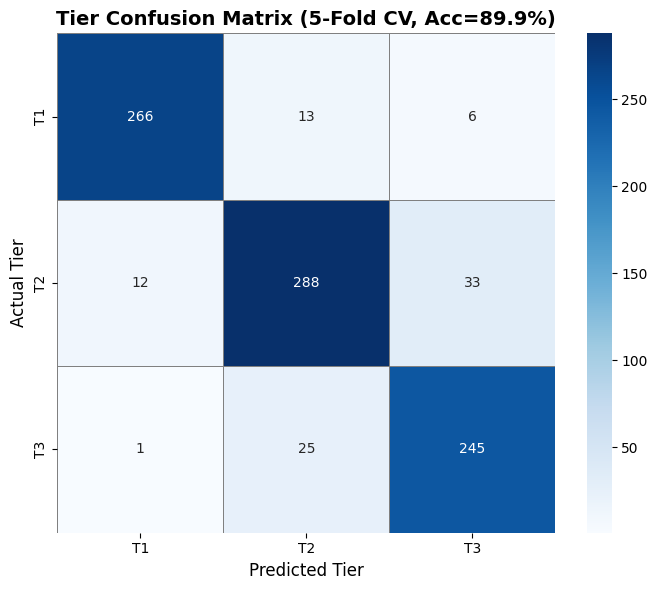

In [19]:
# ── 8.1 Confusion Matrix Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=tier_order, yticklabels=tier_order,
            linewidths=0.5, linecolor='gray', ax=ax)

ax.set_xlabel('Predicted Tier', fontsize=12)
ax.set_ylabel('Actual Tier', fontsize=12)
ax.set_title(f'Tier Confusion Matrix (5-Fold CV, Acc={tier_m*100:.1f}%)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_v4_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

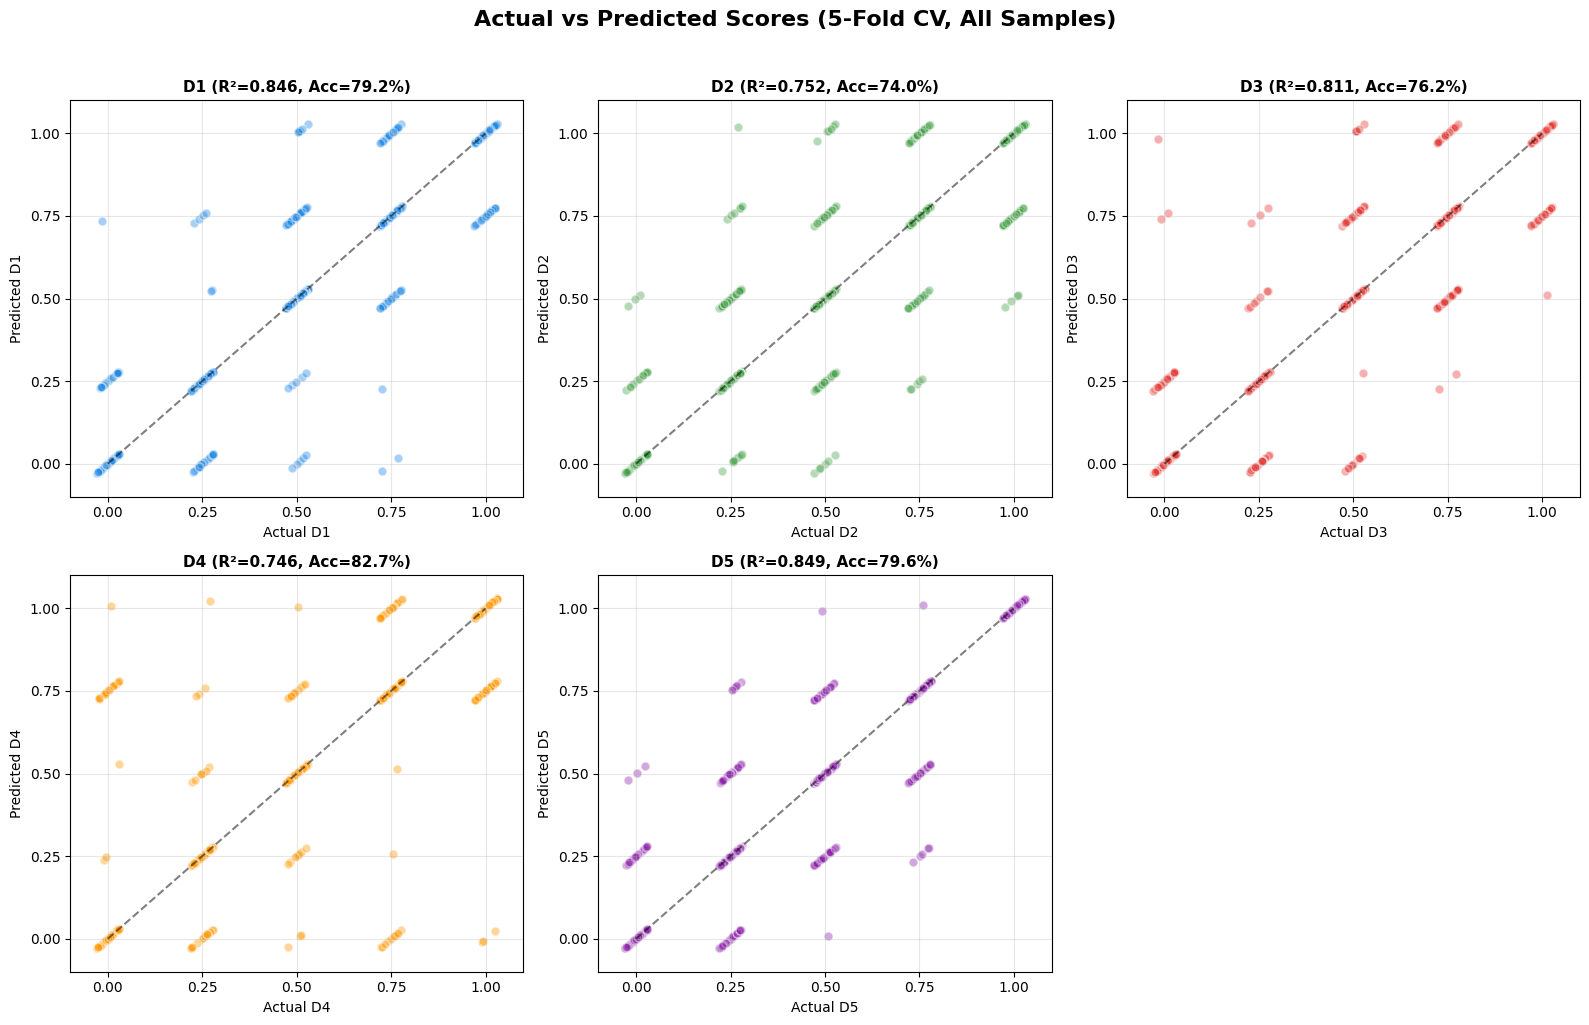

In [20]:
# ── 8.2 Actual vs Predicted Scatter Plots (all 5 dims) ───────────────────────
all_actual = np.vstack(all_actual_scores)
all_pred = np.vstack(all_pred_scores)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Actual vs Predicted Scores (5-Fold CV, All Samples)',
             fontsize=16, fontweight='bold', y=1.02)

colors = ['#1E88E5', '#43A047', '#E53935', '#FF9800', '#8E24AA']
positions = [(0,0), (0,1), (0,2), (1,0), (1,1)]

for i, (dim, color, pos) in enumerate(zip(dim_names, colors, positions)):
    ax = axes[pos[0]][pos[1]]
    jitter = np.random.RandomState(42).uniform(-0.03, 0.03, size=len(all_actual))
    ax.scatter(all_actual[:, i] + jitter, all_pred[:, i] + jitter,
              alpha=0.4, color=color, edgecolors='white', s=40)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5)
    ax.set_xlabel(f'Actual {dim}', fontsize=10)
    ax.set_ylabel(f'Predicted {dim}', fontsize=10)
    ax.set_title(f'{dim} (R\u00b2={cv_results[dim]["R2"]:.3f}, Acc={cv_results[dim]["Acc"]:.1%})',
                fontsize=11, fontweight='bold')
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(True, alpha=0.3)

axes[1][2].set_visible(False)

plt.tight_layout()
plt.savefig('viz_v4_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

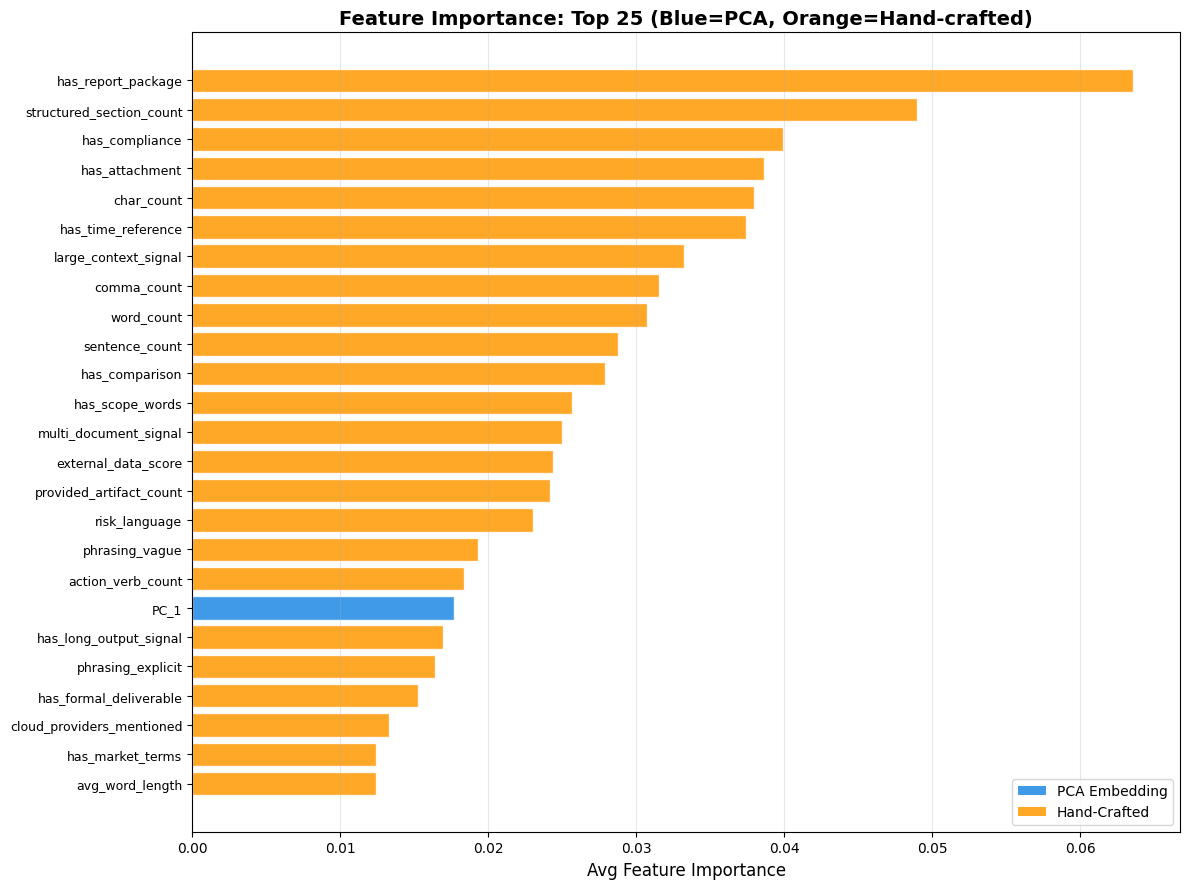


Hand-crafted feature importance ranking:
  has_report_package             0.0636
  structured_section_count       0.0490
  has_compliance                 0.0399
  has_attachment                 0.0387
  char_count                     0.0380
  has_time_reference             0.0374
  large_context_signal           0.0332
  comma_count                    0.0315
  word_count                     0.0307
  sentence_count                 0.0288
  has_comparison                 0.0279
  has_scope_words                0.0257
  multi_document_signal          0.0250
  external_data_score            0.0244
  provided_artifact_count        0.0242
  risk_language                  0.0230
  phrasing_vague                 0.0193
  action_verb_count              0.0183
  has_long_output_signal         0.0170
  phrasing_explicit              0.0164
  has_formal_deliverable         0.0153
  cloud_providers_mentioned      0.0133
  has_market_terms               0.0124
  avg_word_length                0.012

In [21]:
# ── 8.3 Feature Importance (Top 25) ──────────────────────────────────────────
importances = np.zeros(X_all_base_s.shape[1])
for est in final_multi_model.estimators_:
    # Importance is over augmented features; take only base features
    imp = est.feature_importances_[:-1]  # exclude tier_pred feature
    importances += imp
importances /= len(final_multi_model.estimators_)

# Top 25
top_n = min(25, len(importances))
top_idx = np.argsort(importances)[-top_n:][::-1]
top_vals = importances[top_idx]
top_labels = [feature_names[i] for i in top_idx]

bar_colors = ['#FF9800' if not lbl.startswith('PC_') else '#1E88E5' for lbl in top_labels]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(range(len(top_labels)), top_vals[::-1],
               color=bar_colors[::-1], alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(top_labels)))
ax.set_yticklabels(top_labels[::-1], fontsize=9)
ax.set_xlabel('Avg Feature Importance', fontsize=12)
ax.set_title('Feature Importance: Top 25 (Blue=PCA, Orange=Hand-crafted)',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#1E88E5', alpha=0.85, label='PCA Embedding'),
    Patch(facecolor='#FF9800', alpha=0.85, label='Hand-Crafted')
], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('viz_v4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print all hand-crafted importances
print("\nHand-crafted feature importance ranking:")
hc_start = N_PCA
hc_imps = importances[hc_start:]
for name, imp in sorted(zip(hc_feature_names, hc_imps), key=lambda x: -x[1]):
    print(f"  {name:<30s} {imp:.4f}")

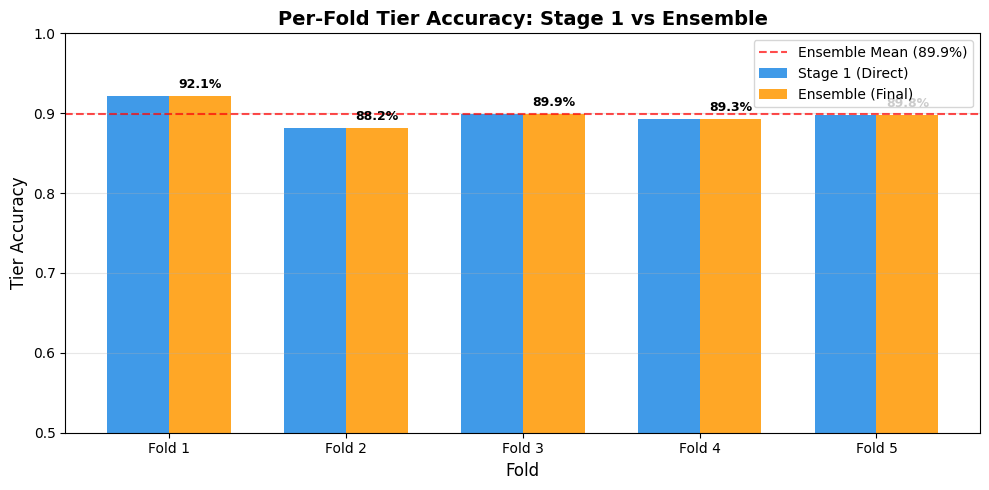

In [22]:
# ── 8.4 Per-Fold Tier Accuracy Bar Chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(N_FOLDS)
width = 0.35

ax.bar(x - width/2, fold_tier_s1_accs, width, label='Stage 1 (Direct)',
       color='#1E88E5', alpha=0.85)
ax.bar(x + width/2, fold_tier_accs, width, label='Ensemble (Final)',
       color='#FF9800', alpha=0.85)

ax.axhline(y=tier_m, color='red', linestyle='--', alpha=0.7,
           label=f'Ensemble Mean ({tier_m:.1%})')

ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Tier Accuracy', fontsize=12)
ax.set_title('Per-Fold Tier Accuracy: Stage 1 vs Ensemble',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for i in range(N_FOLDS):
    ax.text(x[i] + width/2, fold_tier_accs[i] + 0.01,
            f'{fold_tier_accs[i]:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_v4_fold_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 — Save Models

In [23]:
# -- Save all pipeline components --------------------------------------------
joblib.dump(final_tier_clf, 'v4_tier_classifier.joblib')
joblib.dump(final_multi_model, 'v4_dimension_classifier.joblib')
joblib.dump(final_scaler, 'v4_scaler.joblib')
joblib.dump(final_pca, 'v4_pca.joblib')
joblib.dump(hc_feature_names, 'v4_handcrafted_feature_names.joblib')

print("Models saved:")
print("  -> v4_tier_classifier.joblib")
print("  -> v4_dimension_classifier.joblib")
print("  -> v4_scaler.joblib")
print("  -> v4_pca.joblib")
print("  -> v4_handcrafted_feature_names.joblib")

Models saved:
  -> v4_tier_classifier.joblib
  -> v4_dimension_classifier.joblib
  -> v4_scaler.joblib
  -> v4_pca.joblib
  -> v4_handcrafted_feature_names.joblib


In [24]:
# -- FINAL SUMMARY ------------------------------------------------------------
print("\n" + "=" * 78)
print("     FINAL SUMMARY - Architecture 3 v4 (5-Fold CV Results)")
print("=" * 78)
print(f"{'Dim':<5} {'Rubric Label':<24} {'MAE':>8} {'RMSE':>8} {'R2':>8} {'Accuracy':>10}")
print("-" * 78)

for dim in dim_names:
    r = cv_results[dim]
    print(f"{dim:<5} {DIMENSION_LABELS[dim]:<24} {r['MAE']:>8.4f} {r['RMSE']:>8.4f} {r['R2']:>8.4f} {r['Acc']:>9.2%}")

print("-" * 78)
print(f"{'Tier Stage1':<30} {s1_m:>45.2%}")
print(f"{'Tier Final':<30} {tier_m:>45.2%}")
print("=" * 78)
print("\nImprovements applied:")
print(f"  - Expanded dataset: {len(df)} prompts")
print("  - Rubric-aligned D3/D5 naming and features")
print("  - D4 remains ML-predicted")
print("  - Direct tier classifier retained")
print("  - Boundary-aware tier policy added")
print(f"  - Cost-sensitive T3 weighting: {T3_RECALL_WEIGHT}x")
print(f"  - Boundary sample weighting: {BOUNDARY_SAMPLE_WEIGHT}x")
print(f"  - PCA: {N_PCA} components")
print(f"  - Hand-crafted features: {len(hc_feature_names)}")
print(f"  - Feature-to-sample ratio: 1:{X_all_base_s.shape[0]/X_all_base_s.shape[1]:.1f}")


     FINAL SUMMARY - Architecture 3 v4 (5-Fold CV Results)
Dim   Rubric Label                  MAE     RMSE       R2   Accuracy
------------------------------------------------------------------------------
D1    Semantic Complexity        0.0582   0.1328   0.8455    79.19%
D2    Domain Specificity         0.0740   0.1512   0.7524    74.01%
D3    Output Formality           0.0675   0.1455   0.8110    76.15%
D4    Research Dependency        0.0689   0.1903   0.7455    82.68%
D5    Context Requirement        0.0554   0.1268   0.8490    79.64%
------------------------------------------------------------------------------
Tier Stage1                                                           89.88%
Tier Final                                                            89.88%

Improvements applied:
  - Expanded dataset: 889 prompts
  - Rubric-aligned D3/D5 naming and features
  - D4 remains ML-predicted
  - Direct tier classifier retained
  - Boundary-aware tier policy added
  - Cost-sensiti

In [25]:
# -- Verify saved models ------------------------------------------------------
l_tier = joblib.load('v4_tier_classifier.joblib')
l_dim = joblib.load('v4_dimension_classifier.joblib')
l_scaler = joblib.load('v4_scaler.joblib')
l_pca = joblib.load('v4_pca.joblib')

v_emb = embed_model.encode(["test prompt"])
v_pca = l_pca.transform(v_emb)
v_hc = extract_handcrafted_features("test prompt")
v_combined = np.hstack([v_pca, np.array([list(v_hc.values())])])
v_scaled = l_scaler.transform(v_combined)
v_tier = l_tier.predict(v_scaled)
v_aug = np.hstack([v_scaled, v_tier.reshape(-1, 1)])
v_pred = l_dim.predict(v_aug)
v_scores = [CLASS_TO_SCORE[c] for c in v_pred[0]]
v_cs = complexity_score(*v_scores)
v_final = choose_final_tier(v_tier[0], TIER_TO_INT[get_tier(v_cs)], v_cs)

print(f"Model verification: D1={v_scores[0]}, D2={v_scores[1]}, "
      f"D3={v_scores[2]}, D4={v_scores[3]}, D5={v_scores[4]}")
print(f"Tier: {INT_TO_TIER[v_final]}")
print("\nArchitecture 3 v4 pipeline complete.")

Model verification: D1=0.0, D2=0.25, D3=0.0, D4=0.0, D5=0.0
Tier: T1

Architecture 3 v4 pipeline complete.
